In [1]:
import os
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error


In [2]:
# Load dataset
df = pd.read_csv(r'ucs_train_data.csv')

# Define features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
n, p = X.shape

# Split data into train and test sets
random_state = 2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Specify the folder to save results
save_folder = f"random_forest_regressor_results_{random_state}"
os.makedirs(save_folder, exist_ok=True)


In [3]:

# Define the model and parameter grid
model = RandomForestRegressor(random_state=2)
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [3, 5, 10],
    "min_samples_split": [2, 5, 7],
    "min_samples_leaf": [1, 2, 4]
}

# Perform Grid Search with Cross-Validation
start_time = time.time()  # Start time for tuning
gcv = GridSearchCV(model, param_grid, cv=5, scoring='r2', verbose=2)
gcv.fit(X_train, y_train)
end_time = time.time()  # End time for tuning
training_time = time.time() - start_time


Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=10; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.0s
[CV] END max_depth=3, min_samples_leaf=1, min_s

In [4]:
# Convert to hours, minutes, and seconds
hours = training_time // 3600
minutes = (training_time % 3600) // 60
seconds = training_time % 60

# Save training time
training_time_path = os.path.join(save_folder, "training_time.txt")

# Print the formatted time
print(f"Training time:{hours:.0f} hours {minutes:.0f} minutes {seconds:.2f} seconds")

# Optionally, save the training time to a file
with open(training_time_path, "w") as file:
    file.write(f"Training time:{hours:.0f} hours {minutes:.0f} minutes {seconds:.2f} seconds")

Training time:0 hours 0 minutes 37.81 seconds


In [5]:
# Print best parameters
best_params = gcv.best_params_
print("Best Parameters:", best_params)
pd.DataFrame([best_params]).to_csv(os.path.join(save_folder, "best_params.csv"), index=False)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [6]:
# Print and save cross-validation results
cv_results = pd.DataFrame(gcv.cv_results_)
print("Cross-Validation Results:\n", cv_results)
cv_results.to_csv(os.path.join(save_folder, "cv_results.csv"), index=False)

Cross-Validation Results:
     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.026895      0.005970         0.004454        0.005614   
1        0.111238      0.010946         0.005307        0.003384   
2        0.198598      0.003292         0.007295        0.003950   
3        0.026751      0.007479         0.000402        0.000804   
4        0.077953      0.003642         0.013861        0.006991   
..            ...           ...              ...             ...   
76       0.073856      0.007739         0.000000        0.000000   
77       0.153325      0.006835         0.006680        0.008182   
78       0.016518      0.000441         0.003172        0.005928   
79       0.070032      0.006658         0.009966        0.008137   
80       0.147858      0.002595         0.008507        0.009815   

    param_max_depth  param_min_samples_leaf  param_min_samples_split  \
0                 3                       1                        2   
1           

In [7]:
cv_results.keys()

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_max_depth', 'param_min_samples_leaf', 'param_min_samples_split',
       'param_n_estimators', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'split3_test_score',
       'split4_test_score', 'mean_test_score', 'std_test_score',
       'rank_test_score'],
      dtype='object')

In [8]:
import os
import pandas as pd

# Extract the best hyperparameter combination
best_params = gcv.best_params_
fold_r2 = [cv_results[f'split{i}_test_score'].mean() for i in range(gcv.n_splits_)]
# Extract the R² for the best hyperparameter combination in each fold
best_fold_r2 = []

# Loop through each fold and get the R² for the best combination
for i in range(gcv.n_splits_):
    # Compare the parameter dictionary for each fold
    best_fold_r2.append(cv_results[f'split{i}_test_score'][cv_results['params'].apply(lambda x: x == best_params)].values[0])


# Print the R² for each fold
print("R2 for each fold:", fold_r2)
# Print the R² for the best combination in each fold
print("R² for the best combination in each fold:", best_fold_r2)

# Save the R² values for each fold to a CSV file
fold_r2_best = pd.DataFrame(fold_r2, columns=["Each fold R2"])
fold_r2_best["Best Combination R2"] = best_fold_r2
fold_r2_best.to_csv(os.path.join(save_folder, "r2_folds_best_combi.csv"), index=False)


print("R² values for each fold and best combination saved successfully.")


R2 for each fold: [0.9059714765435852, 0.9429380600322849, 0.8262962554623261, 0.8712151778509032, 0.9233568012511029]
R² for the best combination in each fold: [0.9562991740701309, 0.9477935548344535, 0.9650449630630686, 0.9467134524779895, 0.9543551643924651]
R² values for each fold and best combination saved successfully.


In [9]:
gcv.best_estimator_

RandomForestRegressor(max_depth=10, n_estimators=50, random_state=2)

In [10]:
best_model = gcv.best_estimator_

In [11]:
gcv.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

In [12]:
# Evaluate the model
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
y_whole_pred = best_model.predict(X)


In [13]:
df.corr()

,Density,DT,GR,RT,UCS
Density,1.000000,-0.273732,0.527352,-0.308097,0.671632
DT,-0.273732,1.000000,-0.575357,0.523795,-0.737522
GR,0.527352,-0.575357,1.000000,-0.505515,0.815905
RT,-0.308097,0.523795,-0.505515,1.000000,-0.508477
UCS,0.671632,-0.737522,0.815905,-0.508477,1.000000


In [14]:
# Define the adjusted R² function
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Compute and save metrics
metrics = {
    "Train": {
        "R2": r2_score(y_train, y_train_pred),
        "Adj R2": adjusted_r2(r2_score(y_train, y_train_pred), len(y_train), X_train.shape[1]),  # Adjusted R2 for train
        "RMSE": root_mean_squared_error(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred),
        "MAE": mean_absolute_error(y_train, y_train_pred),
        "MAPE": mean_absolute_percentage_error(y_train, y_train_pred),
        "MaxE": np.max(np.abs(y_train - y_train_pred)),
        "MinE": np.min(np.abs(y_train - y_train_pred)),
    },
    "Test": {
        "R2": r2_score(y_test, y_test_pred),
        "Adj R2": adjusted_r2(r2_score(y_test, y_test_pred), len(y_test), X_test.shape[1]),  # Adjusted R2 for test
        "RMSE": root_mean_squared_error(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred),
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_test_pred),
        "MaxE": np.max(np.abs(y_test - y_test_pred)),
        "MinE": np.min(np.abs(y_test - y_test_pred)),
    },
    "Whole": {
        "R2": r2_score(y, y_whole_pred),
        "Adj R2": adjusted_r2(r2_score(y, y_whole_pred), len(y), X.shape[1]),  # Adjusted R2 for whole dataset
        "RMSE": root_mean_squared_error(y, y_whole_pred),
        "MSE": mean_squared_error(y, y_whole_pred),
        "MAE": mean_absolute_error(y, y_whole_pred),
        "MAPE": mean_absolute_percentage_error(y, y_whole_pred),
        "MaxE": np.max(np.abs(y - y_whole_pred)),
        "MinE": np.min(np.abs(y - y_whole_pred)),
    }
}

# Save metrics to CSV
metrics_df = pd.DataFrame(metrics)
metrics_csv_path = os.path.join(save_folder, "metrics.csv")
metrics_df.to_csv(metrics_csv_path, index=True)

# Display the metrics DataFrame
metrics_df

,Train,Test,Whole
R2,0.992947,0.986360,0.992043
Adj R2,0.992744,0.984600,0.991862
RMSE,0.739969,0.820810,0.756828
MSE,0.547554,0.673730,0.572789
MAE,0.428654,0.596980,0.462319
MAPE,0.011327,0.017392,0.012540
MaxE,3.656587,2.659264,3.656587
MinE,0.000472,0.043309,0.000472


In [15]:
# Create a single Excel file with multiple sheets
excel_path = os.path.join(save_folder, "results.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    pd.DataFrame({"y_test": y_test, "y_test_pred": y_test_pred}).to_excel(writer, sheet_name="Test", index=False)
    pd.DataFrame({"y_train": y_train, "y_train_pred": y_train_pred}).to_excel(writer, sheet_name="Train", index=False)
    pd.DataFrame({"y_whole": y, "y_whole_pred": y_whole_pred}).to_excel(writer, sheet_name="Whole", index=False)
    pd.DataFrame({"y_whole": y, "y_whole_pred": y_whole_pred}).to_excel(writer, sheet_name="Whole", index=False)

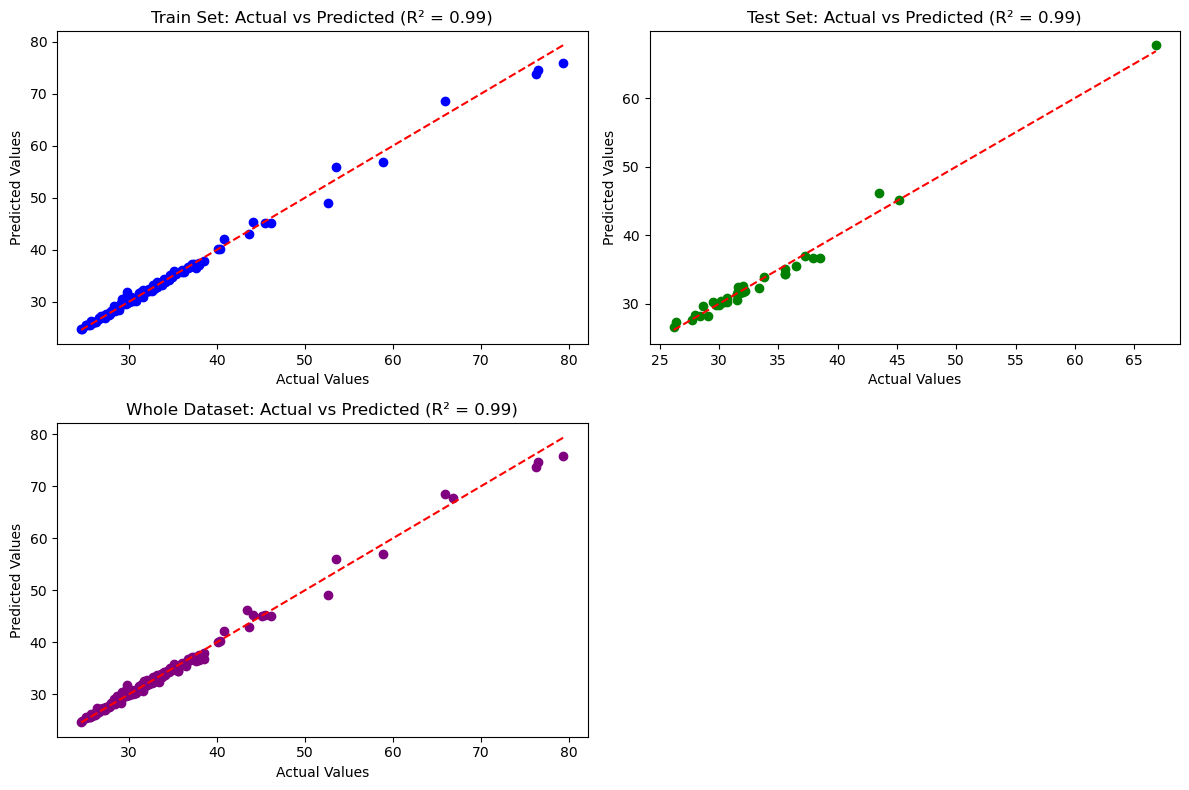

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Calculate R² for each dataset
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
whole_r2 = r2_score(y, y_whole_pred)

# Optional: Visualizing the actual vs predicted values for train, test, and whole dataset
plt.figure(figsize=(12, 8))

# Train Set
plt.subplot(2, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')
plt.title(f"Train Set: Actual vs Predicted (R² = {train_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Test Set
plt.subplot(2, 2, 2)
plt.scatter(y_test, y_test_pred, color='green')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title(f"Test Set: Actual vs Predicted (R² = {test_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# Whole Dataset
plt.subplot(2, 2, 3)
plt.scatter(y, y_whole_pred, color='purple')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--')
plt.title(f"Whole Dataset: Actual vs Predicted (R² = {whole_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "Resutls.png"), dpi=500)
plt.show()



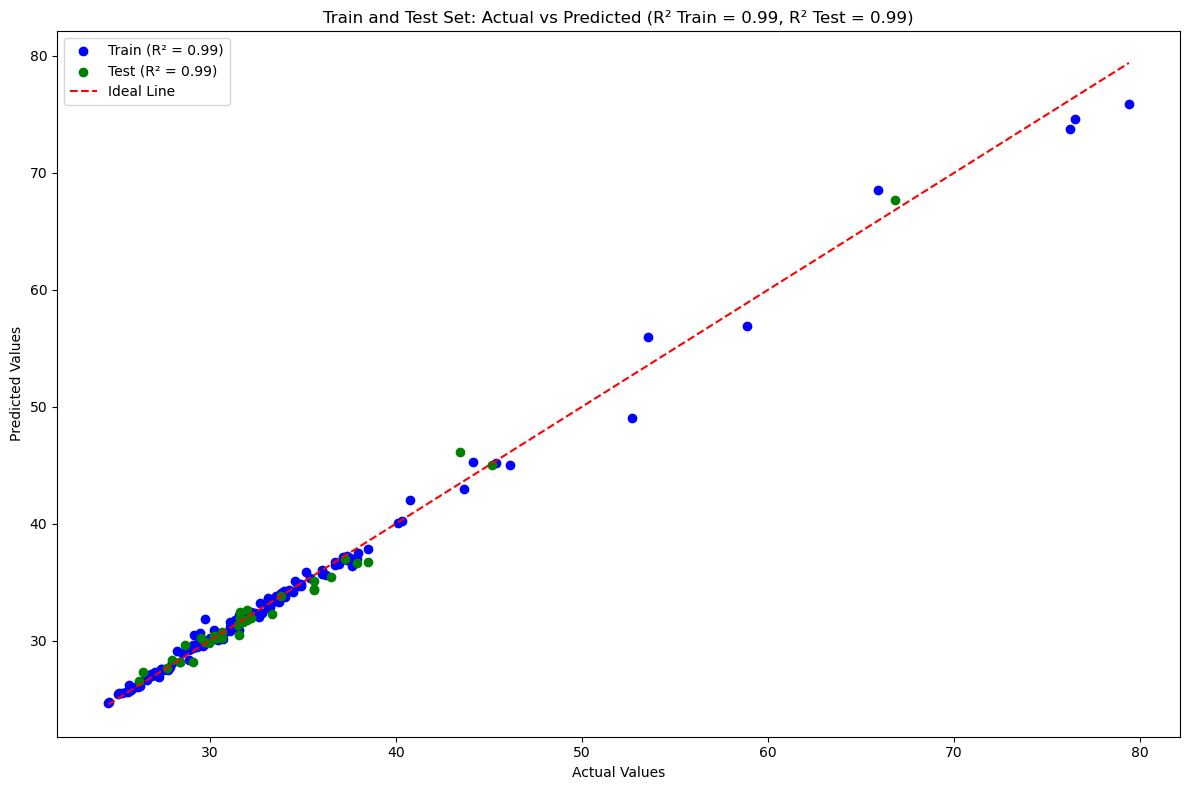

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


# Optional: Visualizing the actual vs predicted values for train and test dataset in the same plot
plt.figure(figsize=(12, 8))

# Combined Plot for Train and Test Set
plt.subplot(1, 1, 1)  # Single plot for both Train and Test
plt.scatter(y_train, y_train_pred, color='blue', label=f'Train (R² = {train_r2:.2f})')
plt.scatter(y_test, y_test_pred, color='green', label=f'Test (R² = {test_r2:.2f})')
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Ideal Line')
plt.title(f"Train and Test Set: Actual vs Predicted (R² Train = {train_r2:.2f}, R² Test = {test_r2:.2f})")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "Results_subplot.png"), dpi=500)
plt.show()


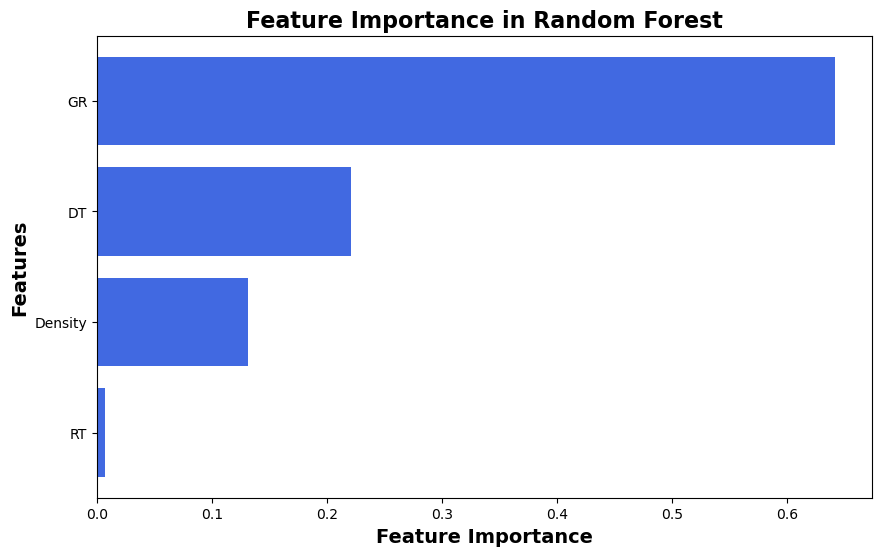

In [18]:

feature_importances = best_model.feature_importances_

# Convert to DataFrame for sorting and visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)
feature_importance= os.path.join(save_folder, "feature_importance.csv")
# Plot feature importance as a bar chart
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance", fontsize=14, fontweight='bold')
plt.ylabel("Features", fontsize=14, fontweight='bold')
plt.title("Feature Importance in Random Forest", fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()  # To display the most important feature at the top
plt.savefig(os.path.join(save_folder, "feature_importance.png"),dpi=1000)
plt.show()


In [19]:

# Save the model
joblib.dump(best_model, os.path.join(save_folder, "best_model_random_forest.pkl"))

['random_forest_regressor_results_2\\best_model_random_forest.pkl']